In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
df  = pd.read_csv('winequality-red.csv', sep=';')
print(df.shape, df.isnull().sum().sum())

(1599, 12) 0


In [13]:
df['label'] = (df['quality'] >= 7).astype(int)

In [14]:
corr = df.drop(columns='quality').corr()['label'].abs().sort_values(ascending=False)
top_features = corr.index[1:7].tolist()   # top 6 features
print("Top features:", top_features)

Top features: ['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'density', 'total sulfur dioxide']


In [7]:
X = df[top_features]
y = df['label']

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8938
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       277
           1       0.76      0.30      0.43        43

    accuracy                           0.89       320
   macro avg       0.83      0.64      0.69       320
weighted avg       0.88      0.89      0.87       320



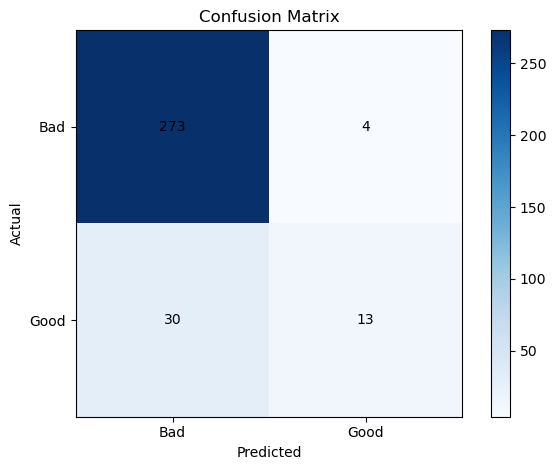

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.colorbar(); plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0,1],['Bad','Good']); plt.yticks([0,1],['Bad','Good'])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center',color='black')
plt.tight_layout(); plt.show()